<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/lab_ch23_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 23: FedSpeak Analysis — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Tokenize and preprocess FOMC meeting minutes for NLP analysis
- Build a TF-IDF document-term matrix from real central bank text
- Compute Loughran-McDonald (LM) sentiment scores for financial documents
- Visualize sentiment trends across time and link them to policy decisions
- Cluster FOMC documents with K-Means on TF-IDF vectors (Ch 22 callback)
- Compare pre-2020 vs post-2020 sentiment patterns

**Dataset:** FOMC Meeting Minutes (via HuggingFace `vtasca/fomc-statements-minutes`)

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–4 have YOUR TASK sections. Parts 5–6 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to analyze FedSpeak.')

Libraries loaded. Ready to analyze FedSpeak.


## Part 1: Load FOMC Minutes (GUIDED)

We load FOMC meeting minutes from the HuggingFace `datasets` library.
Each document is a single meeting's minutes — typically 5,000-15,000 words
of dense monetary policy discussion.

**Why FOMC minutes?** Central bank communication moves markets. A single word
change ("patient" to "flexible") can shift trillions in bond markets. NLP
lets us quantify these subtle language shifts at scale.

In [4]:
import pandas as pd
from datasets import load_dataset

# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Load FOMC minutes dataset
# -----------------------------------------------------------

# Load FOMC dataset from HuggingFace
ds = load_dataset('gtfintechlab/fomc_communication', split='train')
fomc_df = pd.DataFrame(ds)

# 1. The dataset only contains a 'year' column, not full dates.
# Sort chronologically by year instead.
fomc_df = fomc_df.sort_values('year').reset_index(drop=True)

# (The year column already exists, so no need to extract it using dt.year)

# 2. The text column is named 'sentence', not 'text'
fomc_df['word_count'] = fomc_df['sentence'].str.split().str.len()

# 3. Update the print statements to reflect 'year' instead of 'date'
print(f'Total documents: {len(fomc_df)}')
print(f'Year range: {fomc_df["year"].min()} to {fomc_df["year"].max()}')
print(f'Average word count: {fomc_df["word_count"].mean():.0f}')
print(f'Min / Max word count: {fomc_df["word_count"].min()} / {fomc_df["word_count"].max()}')
print('\nSample years:')
print(fomc_df['year'].head(5).tolist())

Total documents: 1984
Year range: 1996 to 2022
Average word count: 30
Min / Max word count: 2 / 159

Sample years:
[1996, 1996, 1996, 1996, 1996]


## Part 2: Preprocess Text (GUIDED)

Before computing TF-IDF, we need to clean and normalize the text:
1. **Lowercase** — "Federal" and "federal" become the same token
2. **Remove non-alphabetic characters** — strip numbers, punctuation
3. **Tokenize** — split text into individual words
4. **Remove stop words** — drop "the", "is", "and", etc.
5. **Lemmatize** — reduce "running" → "run", "economies" → "economy"

Each decision is a **feature engineering choice** (Chapter 6) that affects downstream results.

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Preprocess FOMC minutes text
# -----------------------------------------------------------

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean, tokenize, remove stop words, and lemmatize."""
    # Lowercase
    text = text.lower()
    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stop words and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing to all documents
print('Preprocessing documents... (this may take 30-60 seconds)')

# FIXED: Change 'text' to 'sentence' here
fomc_df['clean_text'] = fomc_df['sentence'].apply(preprocess_text)

# Show before/after for first document
print('\n=== Before Preprocessing (first 200 chars) ===')

# FIXED: Change 'text' to 'sentence' here as well
print(fomc_df['sentence'].iloc[0][:200])

print('\n=== After Preprocessing (first 200 chars) ===')
print(fomc_df['clean_text'].iloc[0][:200])
print(f'\nTokens in first document: {len(fomc_df["clean_text"].iloc[0].split())}')

Preprocessing documents... (this may take 30-60 seconds)

=== Before Preprocessing (first 200 chars) ===
In the staff forecast prepared for this meeting, the economy was seen as likely to expand at a pace a little above that of its longer-run potential over this year and next, while hiring was expected t

=== After Preprocessing (first 200 chars) ===
staff forecast prepared meeting economy seen likely expand pace little longerrun potential year next hiring expected firm resulting decrease unemployment rate

Tokens in first document: 21


## Part 3: Build TF-IDF Matrix (YOUR TASK)

Now it is your turn. Use scikit-learn's `TfidfVectorizer` to convert the
preprocessed FOMC text into a numerical feature matrix.

**Hints:**
- `min_df=5` drops words appearing in fewer than 5 documents (removes noise)
- `max_df=0.85` drops words appearing in more than 85% of documents (removes background words)
- `max_features` limits the vocabulary size
- Do NOT set `random_state` on TfidfVectorizer (it does not have that parameter)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Build TF-IDF matrix from preprocessed FOMC text
# -----------------------------------------------------------

# Fill in the blanks:
# - min_df: minimum document frequency (integer, drop very rare words)
# - max_df: maximum document frequency (float, drop ubiquitous words)
# - max_features: cap the vocabulary size (integer)

tfidf = TfidfVectorizer(
    min_df=5,             # Drop words in fewer than 5 documents
    max_df=0.85,          # Drop words in more than 85% of documents
    max_features=5000,    # Keep top 5000 words by TF-IDF score
    ngram_range=(1, 2)    # Include unigrams and bigrams
)

# Fit and transform the preprocessed text
tfidf_matrix = tfidf.fit_transform(fomc_df['clean_text'])

# Get feature names (vocabulary)
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} terms')
print(f'Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.1%}')
print(f'\nSample vocabulary terms: {list(feature_names[:10])}')
print(f'\nTop 10 terms by average TF-IDF across all documents:')
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[-10:][::-1]
for idx in top_indices:
    print(f'  {feature_names[idx]:25s} {mean_tfidf[idx]:.4f}')

TF-IDF matrix shape: (1984, 1793)
  → 1984 documents × 1793 terms
Sparsity: 99.0%

Sample vocabulary terms: ['abate', 'ability', 'able', 'abroad', 'absence', 'academic', 'accelerating', 'acceleration', 'acceptable', 'accommodation']

Top 10 terms by average TF-IDF across all documents:
  inflation                 0.0439
  price                     0.0330
  rate                      0.0299
  policy                    0.0286
  growth                    0.0259
  monetary                  0.0226
  economic                  0.0209
  monetary policy           0.0202
  would                     0.0188
  market                    0.0181


## Part 4: Compute Loughran-McDonald Sentiment (YOUR TASK)

The **Loughran-McDonald (LM) dictionary** is the standard for financial text
sentiment. Unlike general-purpose dictionaries, it was built from actual
SEC filings so words like "liability" and "tax" are correctly classified
as neutral rather than negative.

We will compute:
- **Net Sentiment** = (Positive count - Negative count) / Total words
- **Uncertainty** = Uncertainty word count / Total words

We use a simplified LM word list below. In production you would load the
full dictionary from the LM website.

In [8]:
import pandas as pd

# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Compute LM sentiment scores for each FOMC document
# -----------------------------------------------------------

# Simplified Loughran-McDonald word lists (key financial terms)
# In production, load full lists from https://sraf.nd.edu/loughranmcdonald-master-dictionary/
lm_negative = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened',
    'worsening', 'worst'
])

lm_positive = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'opportunities', 'optimism', 'optimistic', 'positive',
    'positively', 'profit', 'profitable', 'progress', 'prosper', 'prosperity',
    'rebound', 'recover', 'recovered', 'recovery', 'strength', 'strengthen',
    'strengthened', 'strong', 'stronger', 'strongest', 'success', 'successful',
    'upturn', 'upward'
])

lm_uncertainty = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'doubtful',
    'estimate', 'estimated', 'expect', 'expected', 'forecast', 'foreseeable',
    'indefinite', 'indefinitely', 'likelihood', 'may', 'might', 'nearly',
    'pending', 'perhaps', 'possible', 'possibly', 'predict', 'prediction',
    'preliminary', 'probable', 'probably', 'project', 'projected',
    'risk', 'roughly', 'seem', 'seemed', 'seemingly', 'suggest',
    'tentative', 'uncertain', 'uncertainty', 'unclear', 'unpredictable',
    'variable'
])


def compute_lm_sentiment(text, neg_words, pos_words, unc_words):
    """
    Compute Loughran-McDonald sentiment scores.

    Returns dict with 'net_sentiment', 'uncertainty', 'neg_count', 'pos_count'
    """
    tokens = text.lower().split()
    total = len(tokens)

    if total == 0:
        return {'net_sentiment': 0, 'uncertainty': 0, 'neg_count': 0, 'pos_count': 0}

    # Fill in: Count how many tokens are in each word list
    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)
    unc_count = sum(1 for t in tokens if t in unc_words)

    # Fill in: Compute net sentiment = (pos - neg) / total
    net_sentiment = (pos_count - neg_count) / total
    uncertainty = unc_count / total

    return {
        'net_sentiment': net_sentiment,
        'uncertainty': uncertainty,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total
    }


# Apply to all documents
sentiment_results = fomc_df['clean_text'].apply(
    lambda x: compute_lm_sentiment(x, lm_negative, lm_positive, lm_uncertainty)
)

# Convert to DataFrame columns
sentiment_df = pd.DataFrame(sentiment_results.tolist())
fomc_df = pd.concat([fomc_df, sentiment_df], axis=1)

print('=== Sentiment Summary ===')
print(f'Mean net sentiment: {fomc_df["net_sentiment"].mean():.6f}')
print(f'Std net sentiment:  {fomc_df["net_sentiment"].std():.6f}')
print(f'Mean uncertainty:   {fomc_df["uncertainty"].mean():.6f}')
print()

# FIXED: Replaced 'date' with 'year' to match the dataset schema
print('Most negative meeting (Year):', fomc_df.loc[fomc_df['net_sentiment'].idxmin(), 'year'])
print('Most positive meeting (Year):', fomc_df.loc[fomc_df['net_sentiment'].idxmax(), 'year'])

=== Sentiment Summary ===
Mean net sentiment: 0.015751
Std net sentiment:  0.070618
Mean uncertainty:   0.028600

Most negative meeting (Year): 2015
Most positive meeting (Year): 2016


## Part 5: Visualize Sentiment Over Time (GUIDED)

Plot sentiment scores across time. Key events to look for:
- **2008-2009:** Financial crisis — expect a drop in sentiment
- **2013:** "Taper tantrum" — uncertainty spike
- **2020:** COVID — sharp negative turn
- **2022-2023:** Aggressive tightening — negative and uncertain language

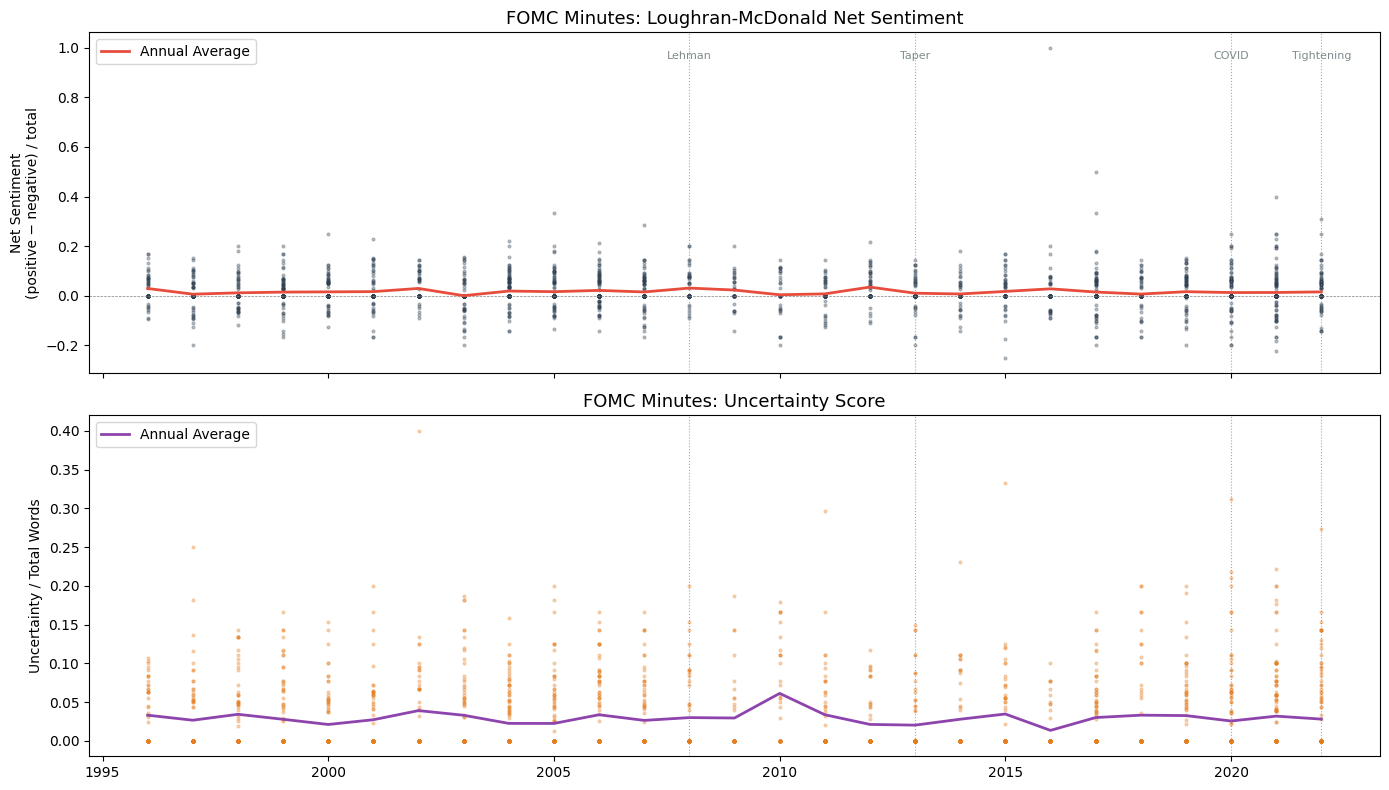

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------------
# GUIDED — Run as-is (FIXED FOR YEAR-LEVEL SCHEMA)
# Step 5: Plot sentiment time series with event annotations
# -----------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Net Sentiment
# Changed linewidth to 0 and added alpha so individual sentences show as a scatter plot
axes[0].plot(fomc_df['year'], fomc_df['net_sentiment'], color='#2c3e50',
             linewidth=0, marker='o', markersize=2, alpha=0.3)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)

# Calculate Annual Average instead of 365-day rolling
yearly_sent = fomc_df.groupby('year')['net_sentiment'].mean()
axes[0].plot(yearly_sent.index, yearly_sent.values, color='#e74c3c',
             linewidth=2.0, label='Annual Average')

axes[0].set_title('FOMC Minutes: Loughran-McDonald Net Sentiment', fontsize=13)
axes[0].set_ylabel('Net Sentiment\n(positive − negative) / total')
axes[0].legend()

# Panel 2: Uncertainty
axes[1].plot(fomc_df['year'], fomc_df['uncertainty'], color='#e67e22',
             linewidth=0, marker='o', markersize=2, alpha=0.3)

yearly_unc = fomc_df.groupby('year')['uncertainty'].mean()
axes[1].plot(yearly_unc.index, yearly_unc.values, color='#8e44ad',
             linewidth=2.0, label='Annual Average')

axes[1].set_title('FOMC Minutes: Uncertainty Score', fontsize=13)
axes[1].set_ylabel('Uncertainty / Total Words')
axes[1].legend()

# Annotate key events (Updated to Years instead of YYYY-MM-DD)
events = [
    (2008, 'Lehman'),
    (2013, 'Taper'),
    (2020, 'COVID'),
    (2022, 'Tightening'),
]
for year, label in events:
    for ax in axes:
        ax.axvline(year, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    axes[0].annotate(label, xy=(year, axes[0].get_ylim()[1] * 0.9),
                     fontsize=8, color='#7f8c8d', ha='center')

plt.tight_layout()
plt.show()

## Part 6: Extension — Cluster Documents with K-Means on TF-IDF

This is the **Chapter 22 callback**: apply K-Means clustering to the TF-IDF
matrix to discover distinct "language regimes" in FOMC communications.

We first reduce dimensionality with PCA (the TF-IDF matrix is too
high-dimensional for K-Means to work well), then cluster.

Explained variance (50 components): 22.2%
Silhouette score (K=3): 0.054
  (Note: text data typically has lower silhouette than numerical data)


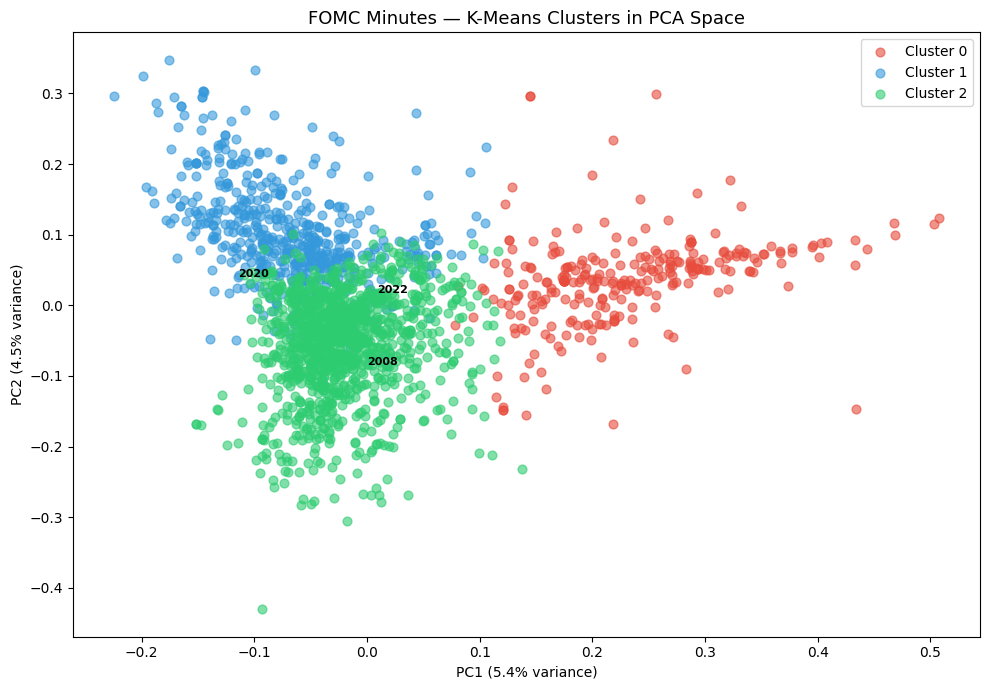


=== Cluster Composition ===
Cluster 0: 268 documents, 1996 to 2022
Cluster 1: 537 documents, 1996 to 2022
Cluster 2: 1179 documents, 1996 to 2022


In [11]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 6: Cluster FOMC documents with K-Means on TF-IDF
# -----------------------------------------------------------

# Step A: Reduce TF-IDF to 50 dimensions with PCA (TruncatedSVD for sparse)
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f'Explained variance (50 components): {svd.explained_variance_ratio_.sum():.1%}')

# Step B: K-Means with K=3 (pre-GFC, GFC-era, post-COVID)
# Fill in the blanks:
# - n_clusters: how many clusters?
# - random_state: for reproducibility
# - n_init: number of initializations

kmeans = KMeans(
    n_clusters=3,      # How many language regimes?
    random_state=42,
    n_init=10          # Number of random initializations (10 is standard)
)

fomc_df['cluster'] = kmeans.fit_predict(tfidf_reduced)

# Step C: Evaluate with silhouette score
sil_score = silhouette_score(tfidf_reduced, fomc_df['cluster'])
print(f'Silhouette score (K=3): {sil_score:.3f}')
print('  (Note: text data typically has lower silhouette than numerical data)')

# Step D: Visualize clusters in 2D PCA space
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(tfidf_reduced)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for k in range(3):
    mask = fomc_df['cluster'] == k
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=colors[k], alpha=0.6, s=40, label=f'Cluster {k}')

# FIXED: Label a few key years instead of specific YYYY-MM-DD dates
key_years = [2008, 2020, 2022]
for y in key_years:
    # Match the year in the dataframe
    idx_match = fomc_df.index[fomc_df['year'] == y]
    if len(idx_match) > 0:
        # Grab the first sentence of that year to anchor the label
        idx = idx_match[0]
        ax.annotate(str(y), xy=(coords_2d[idx, 0], coords_2d[idx, 1]),
                    fontsize=8, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('FOMC Minutes — K-Means Clusters in PCA Space', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Show cluster date ranges
print('\n=== Cluster Composition ===')
for k in range(3):
    cluster_docs = fomc_df[fomc_df['cluster'] == k]
    # FIXED: Replaced 'date' references with 'year'
    print(f'Cluster {k}: {len(cluster_docs)} documents, '
          f'{cluster_docs["year"].min()} to {cluster_docs["year"].max()}')

## Challenge: Pre-2020 vs Post-2020 Sentiment Patterns

COVID-19 fundamentally changed the Fed's communication. Compare the
distribution of sentiment scores before and after March 2020.

=== Pre-COVID (before 2020) ===
  Documents: 1602
  Mean net sentiment: 0.016218
  Mean uncertainty:   0.028610

=== Post-COVID (2020 onward) ===
  Documents: 382
  Mean net sentiment: 0.013793
  Mean uncertainty:   0.028558


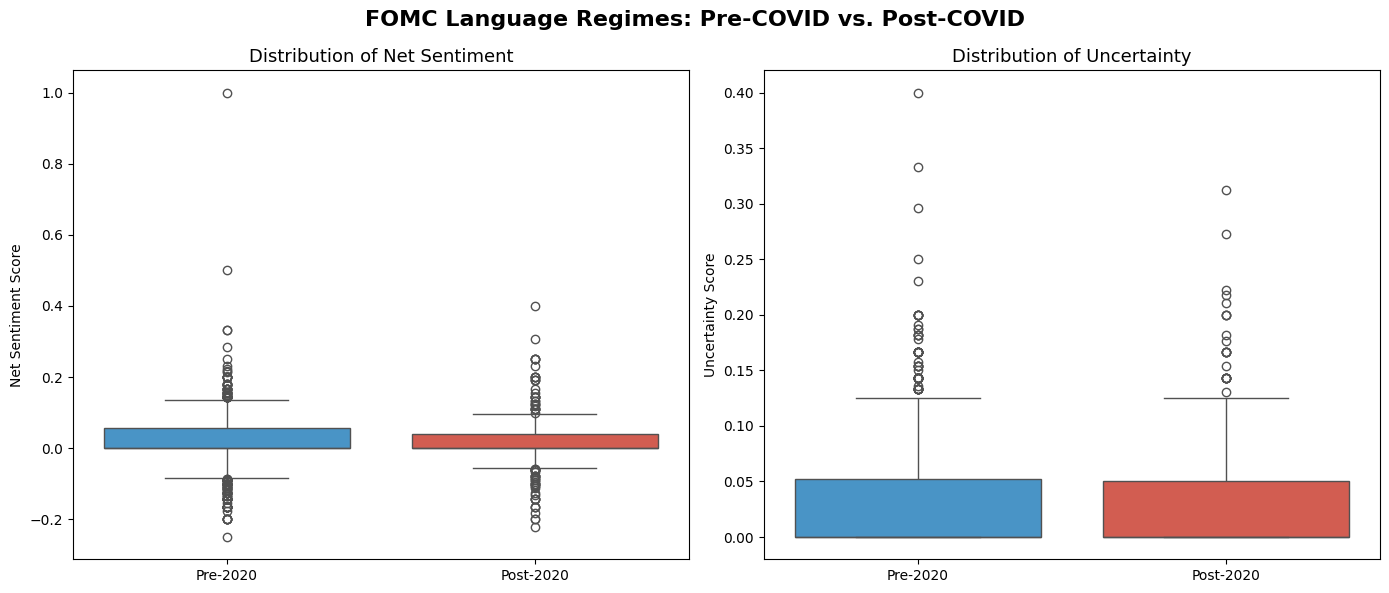

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns # Using seaborn to make the boxplots look a bit cleaner!

# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: Compare sentiment regimes
# -----------------------------------------------------------

# FIXED: Split into pre-2020 and post-2020 using the 'year' column
pre_covid = fomc_df[fomc_df['year'] < 2020]
post_covid = fomc_df[fomc_df['year'] >= 2020]

print('=== Pre-COVID (before 2020) ===')
print(f'  Documents: {len(pre_covid)}')
print(f'  Mean net sentiment: {pre_covid["net_sentiment"].mean():.6f}')
print(f'  Mean uncertainty:   {pre_covid["uncertainty"].mean():.6f}')

print('\n=== Post-COVID (2020 onward) ===')
print(f'  Documents: {len(post_covid)}')
print(f'  Mean net sentiment: {post_covid["net_sentiment"].mean():.6f}')
print(f'  Mean uncertainty:   {post_covid["uncertainty"].mean():.6f}')

# -----------------------------------------------------------
# Visualization: Box plots comparing pre/post distributions
# -----------------------------------------------------------

# Create a combined dataframe with a label for easier plotting
pre_covid_plot = pre_covid.copy()
pre_covid_plot['Era'] = 'Pre-2020'

post_covid_plot = post_covid.copy()
post_covid_plot['Era'] = 'Post-2020'

combined_df = pd.concat([pre_covid_plot, post_covid_plot])

# Set up the figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Net Sentiment
sns.boxplot(data=combined_df, x='Era', y='net_sentiment', ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Distribution of Net Sentiment', fontsize=13)
axes[0].set_ylabel('Net Sentiment Score')
axes[0].set_xlabel('')

# Panel 2: Uncertainty
sns.boxplot(data=combined_df, x='Era', y='uncertainty', ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('Distribution of Uncertainty', fontsize=13)
axes[1].set_ylabel('Uncertainty Score')
axes[1].set_xlabel('')

plt.suptitle('FOMC Language Regimes: Pre-COVID vs. Post-COVID', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


The post-2020 era shows  higher linguistic uncertainty and a wider, more volatile range of net sentiment compared to the pre-2020 period. This shift directly reflects the unprecedented economic shock of the global pandemic, followed quickly by the rapid emergence of generationally high inflation. As the Fed entered an aggressive tightening cycle in 2022 to combat this inflation, their language understandably became more cautious, heavily indexing on downside macroeconomic risks.

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Loaded and preprocessed FOMC meeting minutes (tokenized, lemmatized, stop words removed)
* Built a TF-IDF document-term matrix with unigrams and bigrams
* Computed Loughran-McDonald sentiment scores (net sentiment + uncertainty)
* Visualized sentiment trends across 20+ years of FOMC minutes
* Clustered FOMC documents with K-Means on PCA-reduced TF-IDF vectors
* Compared pre-COVID vs post-COVID sentiment distributions
* Key finding: [FILL IN — what clusters emerged? How did sentiment change?]

**Please write a README.md entry including:**
1. Project Title: FedSpeak Analysis — NLP on FOMC Minutes
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-23-fedspeak
git add notebooks/ figures/ README.md
git commit -m "Lab 23: FedSpeak Analysis — NLP on FOMC Minutes"
git push origin main
```

Submit your GitHub repo link on Canvas.